In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from network import generate_base_network

# 1. Generate the base demand data from our module
df_network = generate_base_network()

# 2. Display the raw dataframe head to verify the columns
display(df_network.head())

,Origin,Destination,Distance_km,Base_Daily_Demand_KG
0,PVG,PEK,1099.57,72000.0
1,PVG,CAN,1203.40,45000.0
2,PVG,CGO,833.32,18000.0
3,PVG,LAX,10415.01,300000.0
4,PVG,ORD,11334.11,240000.0


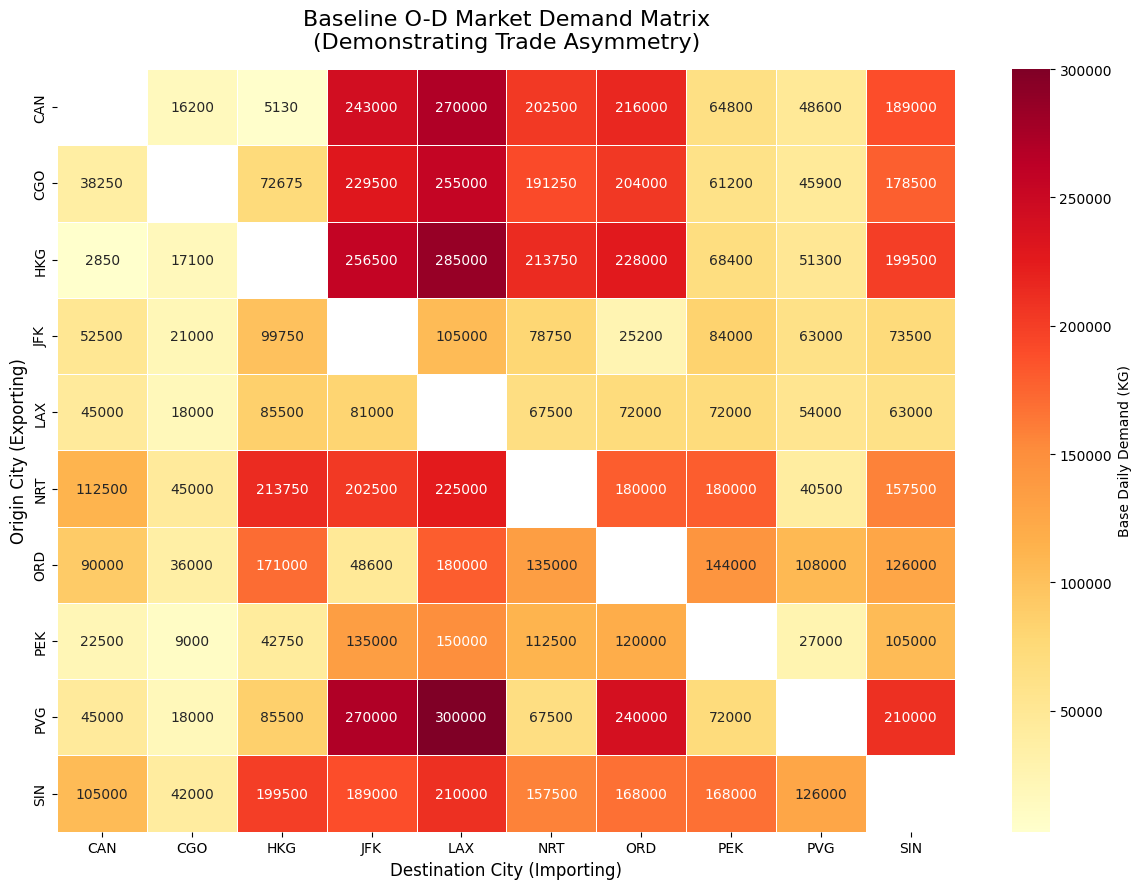

In [2]:
# 1. Pivot the dataframe to create an Origin x Destination matrix
# Rows = Origin, Columns = Destination, Values = Demand
demand_matrix = df_network.pivot(
    index='Origin', 
    columns='Destination', 
    values='Base_Daily_Demand_KG'
)

# 2. Set up the matplotlib figure size
plt.figure(figsize=(12, 9))

# 3. Draw the heatmap using seaborn
sns.heatmap(
    demand_matrix, 
    annot=True,          # Show the actual numbers inside the cells
    fmt=".0f",           # Format numbers as integers (no decimals)
    cmap="YlOrRd",       # Yellow-Orange-Red color scale (Red = High Demand)
    linewidths=.5,       # Add gridlines between cells
    cbar_kws={'label': 'Base Daily Demand (KG)'}
)

# 4. Add professional formatting
plt.title('Baseline O-D Market Demand Matrix\n(Demonstrating Trade Asymmetry)', fontsize=16, pad=15)
plt.ylabel('Origin City (Exporting)', fontsize=12)
plt.xlabel('Destination City (Importing)', fontsize=12)

# 5. Render the plot
plt.tight_layout()
plt.show()